# M1 — The Tenor Trade: Buying Long, Selling Short

**What does the price difference between tenors pay us to take on?** Buy capacity for 36 months, then find paying customers each month. “Selling short” means short-duration service contracts. No first-year customer contract protects this example. Allow 10–15 minutes; read [Notebook 3](03_rental_quotes_to_implied_forward_curve.ipynb) first.

## See the article's actual published price curve

The first chart transcribes Figure 1 of Liquid Compute's [The Tenor Trade](https://liquidcompute.com/research/the-tenor-trade), published September 2026 and inspected September 28, 2026. These are the article's **reported B300 prices**, not invented teaching inputs or independently verified executable quotes. They are a dated snapshot, not a live feed.

This is a **rental term-price curve**: the horizontal axis is commitment length, not the calendar date of future delivery. A three-year rate applies across the whole contract. A separately quoted future-period index forward is a different product.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

1M less 36M: USD 1.05/GPU-hour
On demand less 36M: USD 1.72/GPU-hour


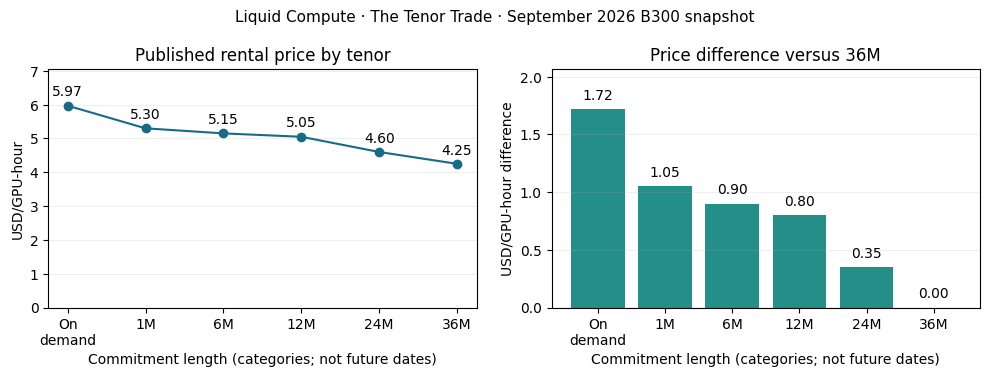

| Tenor | Published USD/GPU-hour | Premium over 36M USD/GPU-hour |
| --- | --- | --- |
| On demand | 5.97 | 1.72 |
| 1M | 5.30 | 1.05 |
| 6M | 5.15 | 0.90 |
| 12M | 5.05 | 0.80 |
| 24M | 4.60 | 0.35 |
| 36M | 4.25 | 0.00 |

In [2]:
from IPython.display import display

from liquid_compute.cashflows import (
    allocate_supplier_prepayment_usd,
    maximum_funding_requirement_usd,
)
from liquid_compute.education import (
    explore_tenor_trade,
    plot_finance_series,
    plot_tenor_heatmap,
    plot_tenor_price_snapshot,
    show_finance_table,
)
from liquid_compute.forward_curves import RentalQuote, imply_rental_blocks
from liquid_compute.hedging import forward_settlements_usd
from liquid_compute.tenor_trade import (
    build_reseller_commitment_scenario,
    tenor_tail_outcome,
)

# Transcribed from the article's Figure 1, not retrieved from a live API.
article_quotes = (
    RentalQuote(1, 5.30),
    RentalQuote(6, 5.15),
    RentalQuote(12, 5.05),
    RentalQuote(24, 4.60),
    RentalQuote(36, 4.25),
)
on_demand = 5.97
monthly_vs_long = 5.30 - 4.25
on_demand_vs_long = 5.97 - 4.25
print(f"1M less 36M: USD {monthly_vs_long:.2f}/GPU-hour")
print(f"On demand less 36M: USD {on_demand_vs_long:.2f}/GPU-hour")
display(
    plot_tenor_price_snapshot(
        article_quotes,
        on_demand_usd_per_gpu_hour=on_demand,
        source_label="Liquid Compute · The Tenor Trade · September 2026 B300 snapshot",
    )
)
show_finance_table(
    ["Tenor", "Published USD/GPU-hour", "Premium over 36M USD/GPU-hour"],
    [["On demand", on_demand, on_demand - 4.25]]
    + [
        [
            f"{q.term_months}M",
            q.rental_usd_per_gpu_hour,
            q.rental_usd_per_gpu_hour - 4.25,
        ]
        for q in article_quotes
    ],
)

The published one-month/36-month difference is **USD 1.05/hour**; on-demand/36-month is **USD 1.72/hour**. Connecting points helps reading; it supplies no missing quotes. The article chart's approximate spread annotation differs from this subtraction; use the displayed endpoints.

A lower long-term price compensates for commitment and commercial terms. It does not guarantee that shorter contracts can be sold continuously at today's price. Payment, service and availability terms must also be compared.

## Build an independent trade with the same structure

Use hypothetical **10 GPUs × 720 hours/month**, bought for **36 months at USD 5/hour**. Initial monthly resale is **USD 6/hour**. Every month's sales must be found anew; all later outcomes are scenarios. The reseller owns rental rights, not GPUs; assume resale is permitted and upstream delivery performs. No hardware proceeds.

Start with zero selling fees, overhead, debt and taxes to isolate gross contribution. **Fill** is the share of purchased hours booked and paid by customers, not processor utilization.

In [3]:
# Editable hypothetical trade; separate from the sourced B300 snapshot.
gpu_count = 10
hours_per_gpu_month = 720
monthly_hours = gpu_count * hours_per_gpu_month
cost_rate = 5.0
initial_resale = 6.0
fill = 1.0
selling_fee = 0.0
service_months = 36

monthly_revenue = monthly_hours * fill * initial_resale
monthly_expense = monthly_hours * cost_rate
monthly_contribution = monthly_revenue * (1 - selling_fee) - monthly_expense
break_even_fill = cost_rate / (initial_resale * (1 - selling_fee))
print(
    f"Monthly: revenue USD {monthly_revenue:,.0f}; expense USD {monthly_expense:,.0f}; "
    f"gross contribution USD {monthly_contribution:,.0f}"
)
print(f"Break-even fill: {break_even_fill:.2%}")

# With no contracted initial revenue, the existing hurdle engine evaluates
# all supplied hours as exposed. Here the reporting period is one year.
annual_inputs = dict(
    upstream_commitment_usd=monthly_hours * 12 * cost_rate,
    contracted_revenue_usd=0.0,
    tail_available_gpu_hours=monthly_hours * 12,
    future_resale_usd_per_gpu_hour=initial_resale,
    placement_fraction=fill,
    selling_fee_fraction=selling_fee,
)
annual = tenor_tail_outcome(**annual_inputs)
print(f"Annual gross if repeated: USD {annual.contribution_usd:,.0f}")

Monthly: revenue USD 43,200; expense USD 36,000; gross contribution USD 7,200
Break-even fill: 83.33%
Annual gross if repeated: USD 86,400


At full fill the hypothetical trade earns **USD 7,200/month**, or **USD 86,400/year** if repeated. These are scenarios, not contracted profits. All 7,200 hours cost money even when some remain unsold.

## The grid matters more than today's spread

$$\text{contribution}=H\,[fP(1-c)-C]$$
$$\text{break-even fill}=\frac{C}{P(1-c)}$$

Here H is purchased hours, f is fill, P resale price, C upstream rate and c the selling-fee fraction. With zero fees, this reduces to cost divided by resale price. At P = 6, fill must reach **83.33%**; at P = 5.50, **90.91%**. A requirement above 100% is unattainable.

The controls vary resale, fill and fees independently. They preserve the fixed examples; editable inputs are the fallback.

| Resale USD/hour | Fill fraction | Annual gross USD | Break-even fill |
| --- | --- | --- | --- |
| 6.00 | 1.00 | 86,400.00 | 0.83 |
| 6.00 | 0.90 | 34,560.00 | 0.83 |
| 6.00 | 0.80 | -17,280.00 | 0.83 |
| 5.50 | 0.90 | -4,320.00 | 0.91 |
| 4.50 | 1.00 | -43,200.00 | 1.11 |

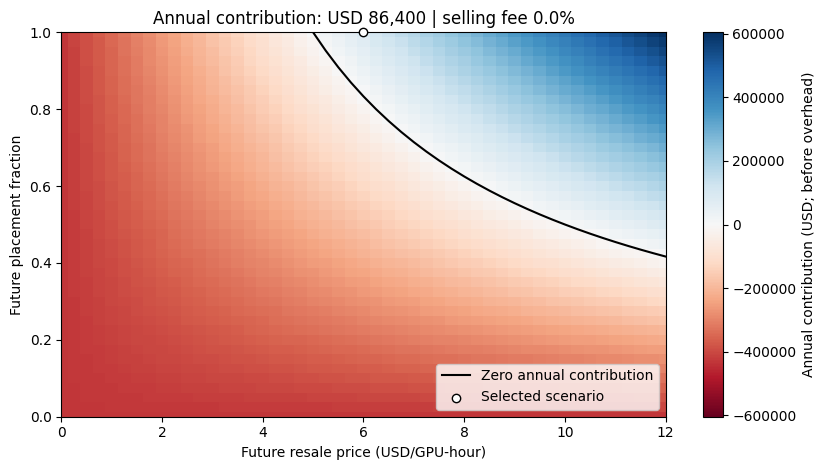

In [4]:
show_finance_table(
    ["Resale USD/hour", "Fill fraction", "Annual gross USD", "Break-even fill"],
    [
        [price, placement, r.contribution_usd, r.break_even_placement_fraction]
        for price, placement in [(6, 1), (6, 0.9), (6, 0.8), (5.5, 0.9), (4.5, 1)]
        for r in [
            tenor_tail_outcome(
                **(
                    annual_inputs
                    | dict(
                        future_resale_usd_per_gpu_hour=price,
                        placement_fraction=placement,
                    )
                )
            )
        ]
    ],
)
display(plot_tenor_heatmap(**annual_inputs, period_label="Annual"))
explore_tenor_trade(**annual_inputs, period_label="Annual");

At USD 6, annual gross falls from **USD 86,400** at full fill to **USD 34,560** at 90% and **−USD 17,280** at 80%. At USD 5.50 and 90%, it is **−USD 4,320** despite resale exceeding cost. At USD 4.50, even full fill loses money.

## Thirty-six monthly resale decisions

Now supply one **synthetic path**, not historical prices or a forecast. Prices and fill weaken together in the middle, then recover. This deliberately stresses the combination; it estimates no statistical correlation. Each month is re-let separately. Unplaced GPU-hours expire, and the supplier obligation continues.

Compare the market resale rate with **revenue per purchased hour = resale × fill**. The latter must cover fixed cost; an attractive rate on only the sold hours can hide a loss.

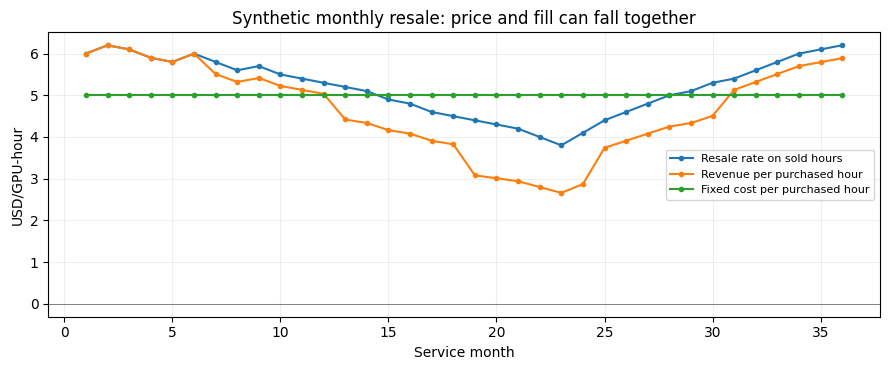

| Year | Revenue USD | Rental expense USD | Gross contribution USD |
| --- | --- | --- | --- |
| 1.00 | 486,972.00 | 432,000.00 | 54,972.00 |
| 2.00 | 303,084.00 | 432,000.00 | -128,916.00 |
| 3.00 | 418,788.00 | 432,000.00 | -13,212.00 |

In [5]:
resale_path = (
    6.0,
    6.2,
    6.1,
    5.9,
    5.8,
    6.0,
    5.8,
    5.6,
    5.7,
    5.5,
    5.4,
    5.3,
    5.2,
    5.1,
    4.9,
    4.8,
    4.6,
    4.5,
    4.4,
    4.3,
    4.2,
    4.0,
    3.8,
    4.1,
    4.4,
    4.6,
    4.8,
    5.0,
    5.1,
    5.3,
    5.4,
    5.6,
    5.8,
    6.0,
    6.1,
    6.2,
)
fill_path = (
    (1.0,) * 6 + (0.95,) * 6 + (0.85,) * 6 + (0.70,) * 6 + (0.85,) * 6 + (0.95,) * 6
)
path = build_reseller_commitment_scenario(
    purchased_gpu_hours=(monthly_hours,) * service_months,
    supplier_usd_per_gpu_hour=(cost_rate,) * service_months,
    billed_fractions=fill_path,
    customer_usd_per_gpu_hour=resale_path,
    customer_contracted=(False,) * service_months,
    selling_fee_fraction=selling_fee,
)
display(
    plot_finance_series(
        {
            "Resale rate on sold hours": resale_path,
            "Revenue per purchased hour": [
                p * f for p, f in zip(resale_path, fill_path)
            ],
            "Fixed cost per purchased hour": [cost_rate] * service_months,
        },
        title="Synthetic monthly resale: price and fill can fall together",
        xlabel="Service month",
        ylabel="USD/GPU-hour",
        x_values=range(1, 37),
    )
)
show_finance_table(
    ["Year", "Revenue USD", "Rental expense USD", "Gross contribution USD"],
    [
        [
            year,
            sum(r.customer_cash_usd for r in path[1 + (year - 1) * 12 : 1 + year * 12]),
            sum(r.supplier_cash_usd for r in path[1 + (year - 1) * 12 : 1 + year * 12]),
            sum(r.contribution_usd for r in path[1 + (year - 1) * 12 : 1 + year * 12]),
        ]
        for year in (1, 2, 3)
    ],
)

The synthetic path shows why a falling resale market and empty hours compound each other. Recovery later does not cancel bills due during weak months. Year 1 earns USD 54,972, but years 2 and 3 lose USD 128,916 and USD 13,212: **USD 87,156 lost overall**. None of these sales was guaranteed at signing.

## Prepayment changes cash timing, not total rent

Assume **30% of the full commitment is paid at signing**. This mirrors the article's structure, but our credit rule is explicit and hypothetical: the remaining 70% of each month's rent settles at month-end. Customers and selling fees also settle at that month-end. There is no additional prepayment charge.

Total rent is **USD 1,296,000**; the initial payment is **USD 388,800**, followed by **USD 25,200/month**. Service expense remains USD 36,000/month. Do not subtract both the prepayment and the full monthly rent. Peak funding includes later cash shortfalls; gross profit divided by the deposit is not an investment return.

In [6]:
prepayment_fraction = 0.30
full_rent = monthly_hours * service_months * cost_rate
upfront = full_rent * prepayment_fraction
remaining_monthly_payment = monthly_hours * cost_rate * (1 - prepayment_fraction)
print(
    f"Direct: USD {upfront:,.0f} now plus {service_months} × "
    f"USD {remaining_monthly_payment:,.0f} = USD {full_rent:,.0f}"
)
payments = allocate_supplier_prepayment_usd(
    [r.supplier_cash_usd for r in path[1:]],
    prepayment_fraction=prepayment_fraction,
)
net_cash = [-payments[0]] + [
    r.customer_cash_usd - r.selling_cost_usd - payments[r.month_offset]
    for r in path[1:]
]
show_finance_table(
    ["Month", "Service expense USD", "Supplier cash payment USD", "Net cash USD"],
    [
        [t, path[t].supplier_cash_usd, payments[t], net_cash[t]]
        for t in (0, 1, 12, 24, 36)
    ],
)
print(f"Total net cash: USD {sum(net_cash):,.0f}")
print(
    f"Peak funding before financing: USD {maximum_funding_requirement_usd(net_cash):,.0f}"
)

Direct: USD 388,800 now plus 36 × USD 25,200 = USD 1,296,000


| Month | Service expense USD | Supplier cash payment USD | Net cash USD |
| --- | --- | --- | --- |
| 0.00 | 0.00 | 388,800.00 | -388,800.00 |
| 1.00 | 36,000.00 | 25,200.00 | 18,000.00 |
| 12.00 | 36,000.00 | 25,200.00 | 11,052.00 |
| 24.00 | 36,000.00 | 25,200.00 | -4,536.00 |
| 36.00 | 36,000.00 | 25,200.00 | 17,208.00 |

Total net cash: USD -87,156
Peak funding before financing: USD 388,800


The deposit goes out before any customer receipts. In this path peak funding is **USD 388,800** and final net cash is **−USD 87,156**, matching total contribution. Changing its percentage changes when cash is needed, while total nominal rent and contribution stay unchanged under this rule. F1 covers financing that cash requirement.

## A partial price hedge: a preview of M2

For a separate one-month experiment, assume actual resale equals the settlement index and all hours sell. Sell forward **one third of purchased hours at hypothetical K = USD 5.50/hour**. This is an assumed hedge term, not a quote extracted from the rental curve. Both legs settle together.

Seller hedge receipt = hedged hours × (K − index). A fall produces a receipt; a rise produces a payment. We reuse M2's settlement engine. The physical sales function remains necessary.

In [7]:
hedged_hours = monthly_hours / 3
# Direct example: all hours sell at index = 3.
physical_revenue = monthly_hours * 3
seller_receipt = hedged_hours * (5.5 - 3)
print(
    f"At index 3: revenue USD {physical_revenue:,.0f}; "
    f"hedge receipt USD {seller_receipt:,.0f}"
)
hedge_rows = []
for index in (3.0, 6.0, 8.0):
    receipt = forward_settlements_usd(
        benchmark_usd_per_gpu_hour=[index],
        strike_usd_per_gpu_hour=5.5,
        hedge_gpu_hours=[hedged_hours],
        settlement_months=[1],
        side="seller",
    )[0].amount_usd
    unhedged = monthly_hours * (index - cost_rate)
    hedge_rows.append([index, unhedged, receipt, unhedged + receipt])
show_finance_table(
    [
        "Index USD/hour",
        "Unhedged gross USD",
        "Seller hedge receipt USD",
        "Hedged gross USD",
    ],
    hedge_rows,
)

At index 3: revenue USD 21,600; hedge receipt USD 6,000


| Index USD/hour | Unhedged gross USD | Seller hedge receipt USD | Hedged gross USD |
| --- | --- | --- | --- |
| 3.00 | -14,400.00 | 6,000.00 | -8,400.00 |
| 6.00 | 7,200.00 | -1,200.00 | 6,000.00 |
| 8.00 | 21,600.00 | -6,000.00 | 15,600.00 |

At index 3, the partial hedge reduces the monthly loss from **USD 14,400 to USD 8,400**; it does not make it profitable. At index 8, it reduces the gain from **USD 21,600 to USD 15,600**. That is the price protection trade-off.

## What remains when hours do not sell?

A financial receipt does not place capacity. Keep the hedge quantity fixed while fill falls to 70%. Below, the index is 6, so the seller pays on the forward despite weak sales. Hardware specifications can also become less attractive, reducing both price and fill. The price hedge provides no physical capacity guarantee.

In [8]:
stress_fill = 0.70
stress_index = 6.0
stress_sales = monthly_hours * stress_fill * stress_index
stress_hedge = forward_settlements_usd(
    benchmark_usd_per_gpu_hour=[stress_index],
    strike_usd_per_gpu_hour=5.5,
    hedge_gpu_hours=[hedged_hours],
    settlement_months=[1],
    side="seller",
)[0].amount_usd
show_finance_table(
    ["70% fill case", "USD"],
    [
        ["Physical revenue", stress_sales],
        ["Full supplier expense", monthly_hours * cost_rate],
        ["Signed hedge receipt", stress_hedge],
        [
            "Combined contribution",
            stress_sales - monthly_hours * cost_rate + stress_hedge,
        ],
    ],
)

| 70% fill case | USD |
| --- | --- |
| Physical revenue | 30,240.00 |
| Full supplier expense | 36,000.00 |
| Signed hedge receipt | -1,200.00 |
| Combined contribution | -6,960.00 |

With 70% fill, physical contribution is **−USD 5,760**; the hedge payment makes it **−USD 6,960**. Hedge size must be considered alongside actual sales. M3 covers benchmark mismatch; M4 covers quantity uncertainty. A lender would still assess placement, basis, counterparty performance and liquidity; an index hedge alone does not guarantee financeable customer revenue.

## Rental curve versus implied future blocks

For continuity with Notebook 3, our **separate hypothetical** one-year/three-year menu is 6/5. Equal monthly hours and matched payment dates imply a years-2–3 allocation of 4.50. It is not a purchasable offer. Do not apply that calculation blindly to the article snapshot: its quotes' payment and service terms are not fully specified. [Ornn's methodology](https://data.ornn.com/docs/forward-curves) likewise distinguishes quoted term rates from implied blocks and retains embedded commercial discounts.

In [9]:
implied_years_2_3 = (36 * 5.0 - 12 * 6.0) / 24
print(f"Hypothetical allocation: (36 × 5 − 12 × 6) / 24 = {implied_years_2_3:.2f}")
blocks = imply_rental_blocks(
    [RentalQuote(12, 6.0), RentalQuote(36, 5.0)],
    delivery_hours_per_gpu=[720] * 36,
)
show_finance_table(
    ["Hypothetical delivery block", "Implied USD/GPU-hour"],
    [
        [
            f"Months {b.start_month_offset + 1}–{b.end_month_offset}",
            b.implied_usd_per_gpu_hour,
        ]
        for b in blocks
    ],
)

Hypothetical allocation: (36 × 5 − 12 × 6) / 24 = 4.50


| Hypothetical delivery block | Implied USD/GPU-hour |
| --- | --- |
| Months 1–12 | 6.00 |
| Months 13–36 | 4.50 |

The supplier still invoices **USD 5/hour across all 36 months**. The 4.50 allocation neither replaces that bill nor forecasts future resale. Our main result depends on prices actually achieved and hours actually sold.

**Takeaways:** Read the tenor price gap, calculate required fill, stress every monthly re-let, and fund the upfront cash. Separate price protection from selling capacity. Today's spread is compensation for obligations and uncertainty, not a locked profit.

**Next:** [M2: Forwards and swaps](M2_forwards_and_swaps.ipynb) develops the hedge; F1 and F4/F7 develop financing. No borrowing capacity or investor return has been inferred here.

Sources: [The Tenor Trade](https://liquidcompute.com/research/the-tenor-trade), Figure 1, supplies the explicitly attributed price snapshot. [Ornn forward curves](https://data.ornn.com/docs/forward-curves) supplies the methodology distinction. The monthly paths, hedge terms and payment-credit rule are independent hypothetical assumptions. No live data or credentials are required.